# Configure SBS Parameters

This notebook should be used as a test for ensuring correct SBS image loading and processing before running the SBS module.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for SBS processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

## Imports

In [2]:
from pathlib import Path

import yaml
from tifffile import imread
import pandas as pd
from snakemake.io import expand
from microfilm.microplot import Microimage
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from lib.shared.configuration_utils import (
    CONFIG_FILE_HEADER,
    create_micropanel,
    random_cmap,
    image_segmentation_annotations,
)
from lib.shared.file_utils import get_filename
from lib.sbs.align_cycles import align_cycles
from lib.shared.log_filter import log_filter
from lib.sbs.compute_standard_deviation import compute_standard_deviation
from lib.sbs.max_filter import max_filter
from lib.sbs.find_peaks import find_peaks
from lib.shared.illumination_correction import apply_ic_field, combine_ic_images
from lib.shared.segment_cellpose import (
    prepare_cellpose,
    estimate_diameters,
    segment_cellpose,
)
from lib.shared.segment_microsam import segment_microsam
from lib.shared.segment_stardist import segment_stardist
from lib.shared.segment_watershed import segment_watershed
from lib.sbs.extract_bases import extract_bases
from lib.sbs.call_reads import call_reads
from lib.sbs.call_cells_T7 import prep_T7_reads, call_cells_T7
from lib.shared.extract_phenotype_minimal import extract_phenotype_minimal
from lib.sbs.eval_mapping import (
    plot_mapping_vs_threshold,
    plot_cell_mapping_heatmap,
    plot_gene_symbol_histogram,
)

KeyboardInterrupt: 

## <font color='red'>SET PARAMETERS</font>

### Parameters for testing SBS processing

- `TEST_PLATE`, `TEST_WELL`, `TEST_TILE`: Plate/well/tile combination used for configuring parameters in this notebook.

### Channels

- `CHANNEL_NAMES`: A list of names for each channel in your SBS image. Should include one channel for DAPI and other channels for bases.
- `CHANNEL_CMAPS`: A list of color maps to use when showing channel microimages. These need to be a Matplotlib or microfilm colormap. We recommend using: `["pure_red", "pure_green", "pure_blue", "pure_cyan", "pure_magenta", "pure_yellow"]`.

In [ ]:
# Define test well and tile
TEST_PLATE = 1
TEST_WELL = "A1"
TEST_TILE = 150
# Derive wildcard dictionary for testing
WILDCARDS = dict(well=TEST_WELL, tile=TEST_TILE)

# Define image channels with DAPI as the first channel
CHANNEL_NAMES = ["DAPI", "G", "T", "A", "C"]
CHANNEL_CMAPS = ["pure_blue", "pure_green", "pure_red", "pure_cyan", "pure_magenta"]

# Remove DAPI channel to get bases
BASES = CHANNEL_NAMES[1:]

## <font color='red'>SET PARAMETERS</font>

### Alignment

- `ALIGNMENT_METHOD`: Methodology for aligning SBS images. Alignment happens automatically within a cycle. Alignment between cycles can occur in one of two ways: 
    - `DAPI`: the DAPI intensity is aligned between cycles. This is recommended if a nuclear stain is captured for **each** round of SBS imaging.
    - `sbs_mean`: the mean intensity is aligned between cycles. This is recommended if a nuclear stain is captured only in the first round of SBS imaging. 
- `KEEP_EXTRAS`: Whether to keep extra channels (that are not imaged in each round) when aligning. Defaults to `FALSE`
    - Set to `FALSE` if a nuclear stain is captured for **each** round of SBS imaging.
    - Set to `TRUE` if a nuclear stain is captured only in the first round of SBS imaging. 

In [ ]:
ALIGNMENT_METHOD = "DAPI"
KEEP_EXTRAS = False
UPSAMPLE_FACTOR = 2

Loading test images...
Aligning test images...
Example aligned image for first cycle:


microplot.py (725): Ignoring specified arguments in this call because figure with num: 1 already exists


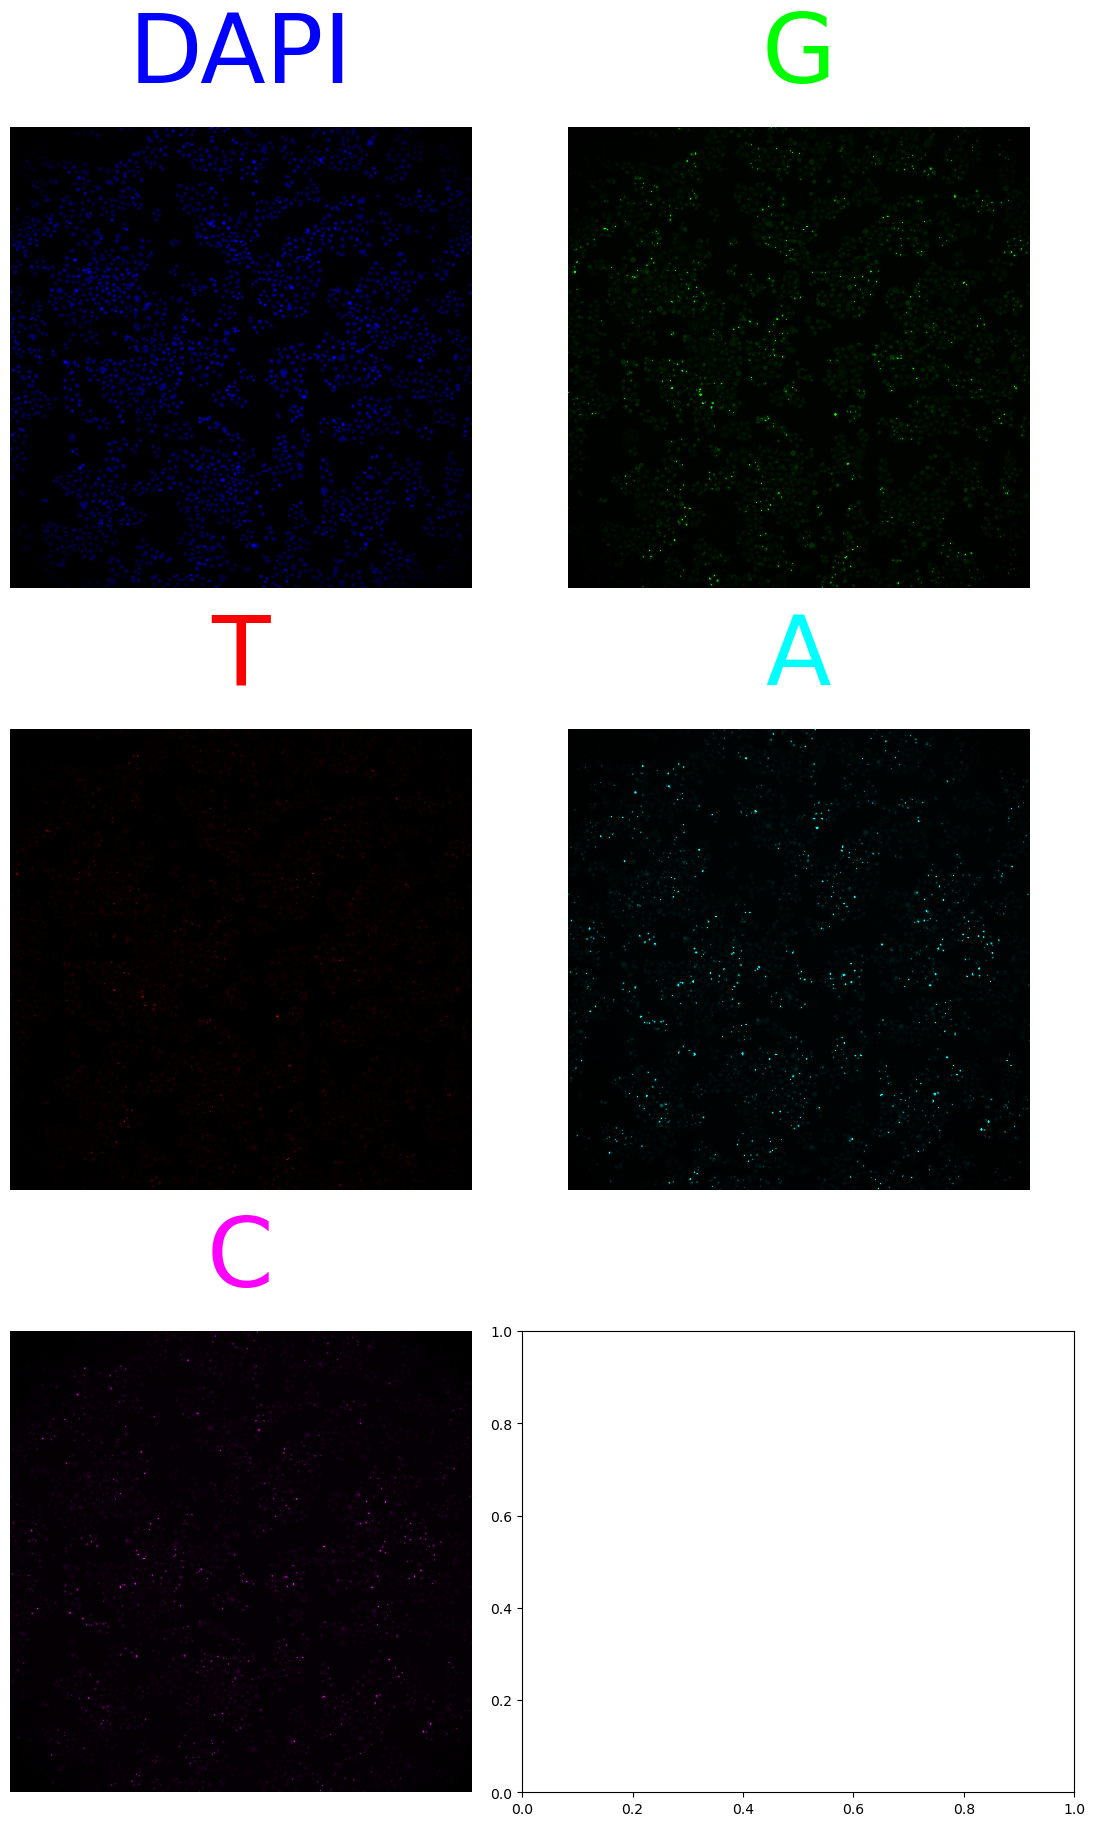

In [ ]:
# load config file
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

# Get paths to the sample files dfs
SBS_SAMPLES_FP = Path(config["preprocess"]["sbs_samples_fp"])
# Load the sample TSV files with pandas
sbs_samples = pd.read_csv(SBS_SAMPLES_FP, sep="\t")
SBS_CYCLES = sorted(list(sbs_samples["cycle"].unique()))

# load test image data
print("Loading test images...")
ROOT_FP = Path(config["all"]["root_fp"])
PREPROCESS_FP = ROOT_FP / "preprocess"
sbs_test_image_paths = expand(
    PREPROCESS_FP
    / "images"
    / "sbs"
    / get_filename(
        {"plate": TEST_PLATE, "well": TEST_WELL, "tile": TEST_TILE, "cycle": "{cycle}"},
        "image",
        "tiff",
    ),
    cycle=SBS_CYCLES,
)
sbs_test_images = [imread(file_path) for file_path in sbs_test_image_paths]


# align cycles
print("Aligning test images...")
aligned = align_cycles(
    sbs_test_images,
    method=ALIGNMENT_METHOD,
    upsample_factor=UPSAMPLE_FACTOR,
    keep_extras=KEEP_EXTRAS,
)

# Create and display micropanel of aligned images
print("Example aligned image for first cycle:")
aligned_microimages = [
    Microimage(
        aligned[0, i, :, :], channel_names=CHANNEL_NAMES[i], cmaps=CHANNEL_CMAPS[i]
    )
    for i in range(aligned.shape[1])
]
aligned_panel = create_micropanel(aligned_microimages, add_channel_label=True)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Spot detection

- `MAXED_WIDTH`: Width parameter used for determining the neighborhood size for finding local maxima. No default value, but `3` is suggested
- `SPOT_DETECTION_METHOD`: Methodology for calling spots: 
    - `STANDARD`: Standard method for calling spots, involving Laplacian of Gaussian correction, and computation of spots across cycles. Spots are identified based on signal intensity and consistency across cycles.
        - `PEAK_WIDTH`: Width parameter used for peak detection, sets neighborhood size for finding local maxima of base channels standard deviation. Defaults to `5`
    - `SPOTIFLOW`: Deep learning based methodology for calling spots. Spots are called independently on all 4 bases of a selected cycle, and then coalesced to ensure minimum distance between spots. If this method is selected, the following parameters are required:
        - `SPOTIFLOW_CYCLE_INDEX`: Cycle to use for spot detection
        - `SPOTIFLOW_MODEL`: Model to use for spot detection (e.g., "general", "hybiss")
        - `SPOTIFLOW_THRESHOLD`: Probability threshold for confidence in spot detection
        - `SPOTIFLOW_MIN_DISTANCE`: Minimum distance (in pixels) required between detected spots

In [ ]:
# Set parameters:
MAXED_WIDTH = 3
SPOT_DETECTION_METHOD = "standard"

if SPOT_DETECTION_METHOD == "standard":
   PEAK_WIDTH = 5
elif SPOT_DETECTION_METHOD == "spotiflow":
   SPOTIFLOW_CYCLE_INDEX = 0
   SPOTIFLOW_MODEL = "general"
   SPOTIFLOW_THRESHOLD = 0.3         
   SPOTIFLOW_MIN_DISTANCE = 1

Detecting candidate reads...
Applying Laplacian-of-Gaussian (LoG) filter...


Computing standard deviation over cycles...
Applying max filter...
Finding peaks...
Example max filtered image for first cycle:


microplot.py (725): Ignoring specified arguments in this call because figure with num: 1 already exists


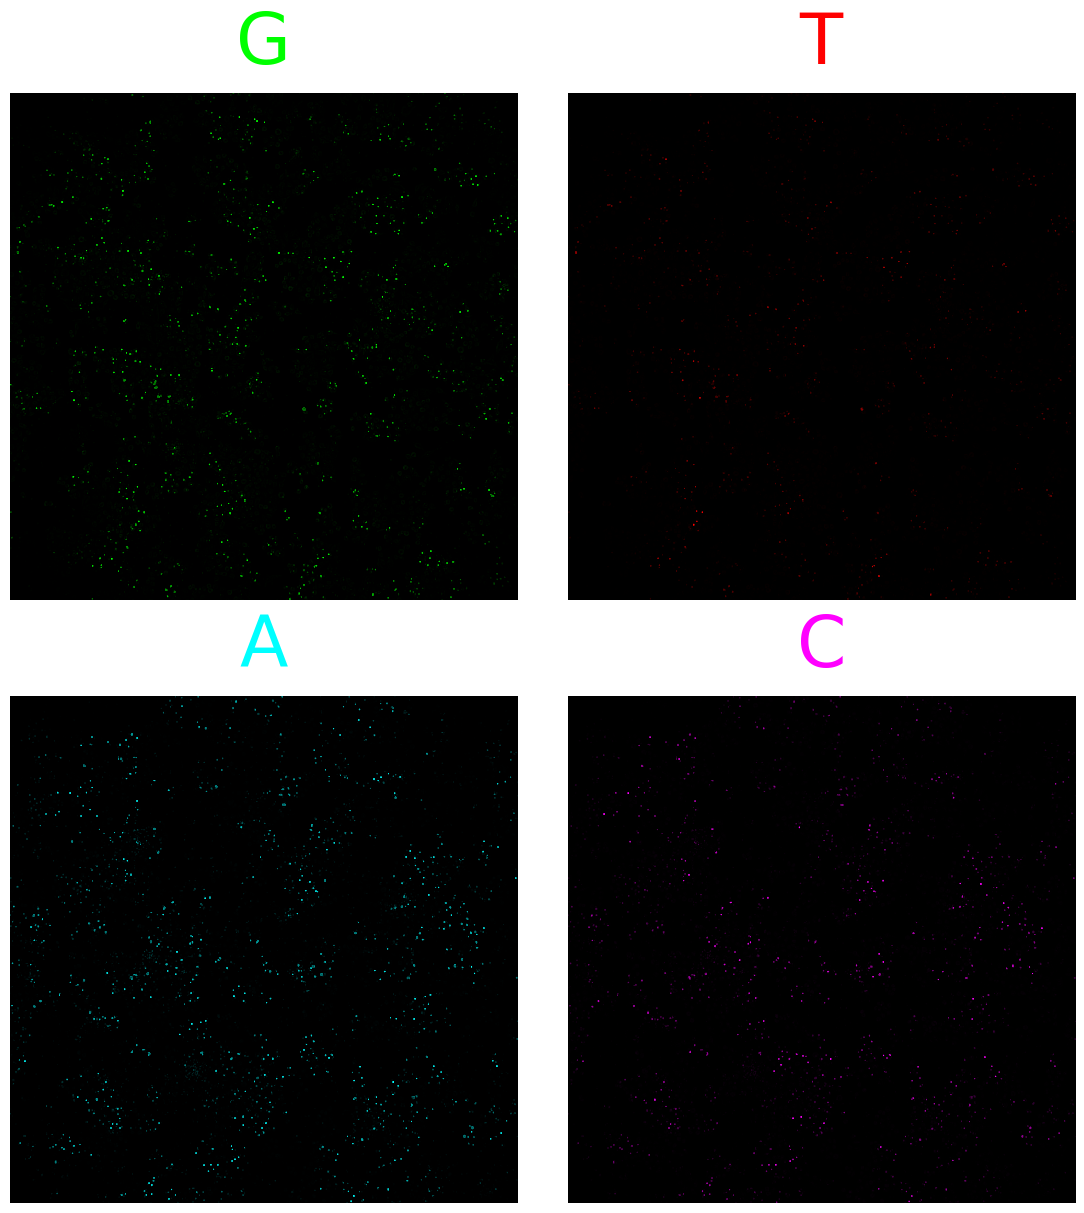

In [ ]:
print("Detecting candidate reads...")

print("Applying Laplacian-of-Gaussian (LoG) filter...")
loged = log_filter(aligned, skip_index=0)

print("Computing standard deviation over cycles...")
standard_deviation = compute_standard_deviation(loged, remove_index=0)

print("Applying max filter...")
maxed = max_filter(loged, width=MAXED_WIDTH, remove_index=0)

print("Finding peaks...")
peaks = find_peaks(standard_deviation, width=PEAK_WIDTH)

# Create and display micropanel of max filtered datas
print("Example max filtered image for first cycle:")
maxed_microimages = [
    Microimage(maxed[0, i, :, :], channel_names=BASES[i], cmaps=CHANNEL_CMAPS[i + 1])
    for i in range(maxed.shape[1])
]
maxed_panel = create_micropanel(maxed_microimages, add_channel_label=True)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Illumination correction and Segmentation

- `SEGMENTATION_CYCLE`: Index of cycle used for illumination correction and segmentation. Typically, this is set to the cycle with the brightest or clearest signal for cell boundaries (there is often the most background signal in the last cycle, so that is often used).
- `CYTO_CHANNEL`: The name of the cytoplasmic channel in your image stack. Typically the channel that best outlines cell boundaries, usually base C.

In [ ]:
# Define cycle to use for segmentation, -1 for last cycle
SEGMENTATION_CYCLE = 1
# Define cytoplasmic channel
CYTO_CHANNEL = None

# Derive DAPI and CYTO indexes
SEGMENTATION_CYCLE_INDEX = SBS_CYCLES.index(SEGMENTATION_CYCLE)
DAPI_INDEX = CHANNEL_NAMES.index("DAPI")
CYTO_INDEX = None

Applying illumination correction to segmentation cycle image...
Preparing nuclei-only segmentation image...
Pre-segmentation images (nuclei only):


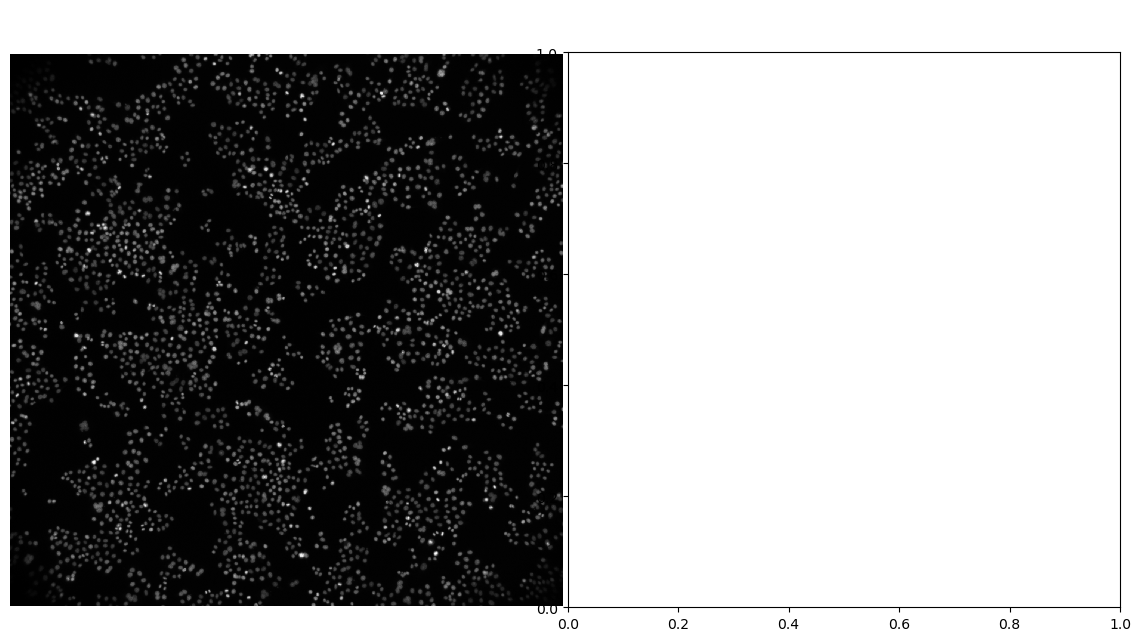

In [ ]:
# Determine the cycle to use for segmentation
sbs_segmentation_cycle = SBS_CYCLES[SEGMENTATION_CYCLE_INDEX]
aligned_image_data_segmentation_cycle = aligned[SEGMENTATION_CYCLE_INDEX]

print("Applying illumination correction to segmentation cycle image...")
# Read the illumination correction file
if KEEP_EXTRAS:
    ic_field_dapi = imread(
        PREPROCESS_FP
        / "ic_fields"
        / "sbs"
        / get_filename(
            {"plate": TEST_PLATE, "well": TEST_WELL, "cycle": 1}, "ic_field", "tiff"
        )
    )
    ic_field_full = imread(
        PREPROCESS_FP
        / "ic_fields"
        / "sbs"
        / get_filename(
            {"plate": TEST_PLATE, "well": TEST_WELL, "cycle": sbs_segmentation_cycle},
            "ic_field",
            "tiff",
        )
    )
    ic_field = combine_ic_images([ic_field_dapi, ic_field_full], [DAPI_INDEX, None])
else:
    ic_field = imread(
        PREPROCESS_FP
        / "ic_fields"
        / "sbs"
        / get_filename(
            {"plate": TEST_PLATE, "well": TEST_WELL, "cycle": sbs_segmentation_cycle},
            "ic_field",
            "tiff",
        )
    )

# Apply illumination correction field
corrected_image_data = apply_ic_field(
    aligned_image_data_segmentation_cycle, correction=ic_field
)

# Prepare corrected image for CellPose segmentation
# NOTE: this process is done during the `segment_cellpose` method below as well
# Use the prepared_cellpose image to test CellPose (see below)
if CYTO_INDEX is not None:
    print("Preparing IC segmentation image for CellPose...")
    cellpose_rgb = prepare_cellpose(
        corrected_image_data,
        DAPI_INDEX,
        CYTO_INDEX,
    )

    # show max filtered data for one round
    print("Pre-segmentation images:")
    pre_seg_microimages = [
        Microimage(cellpose_rgb[2], channel_names="Dapi"),
        Microimage(cellpose_rgb[1], channel_names="Cyto"),
    ]
    pre_seg_panel = create_micropanel(pre_seg_microimages, add_channel_label=True)
    plt.show()
else:
    print("Preparing nuclei-only segmentation image...")
    # Extract the DAPI channel for visualization
    dapi_image = corrected_image_data[DAPI_INDEX]
        
    # Show only the DAPI channel
    print("Pre-segmentation images (nuclei only):")
    pre_seg_microimages = [
        Microimage(dapi_image, channel_names="Dapi")
    ]
    pre_seg_panel = create_micropanel(pre_seg_microimages, add_channel_label=True)
    plt.show()

## <font color='red'>SET PARAMETERS</font>

### Segmentation

#### Select Segmentation Method
- `SEGMENTATION_METHOD`: Choose from "cellpose", "microsam", or "stardist" for cell segmentation.

#### Common Parameters
- `GPU`: Set to True to use GPU acceleration (if available)
- `RECONCILE`: Method for reconciling nuclei and cell masks (typically "contained_in_cells", which allows more than one nucleus per cell and is useful for cells that are dividing)

#### Cellpose Parameters (if using "cellpose")
- `CELLPOSE_MODEL`: CellPose model to use ("cyto", "cyto2", or "cyto3"). Default is "cyto3".
- `FLOW_THRESHOLD`: Flow threshold for Cellpose segmentation. Default is 0.4.
- `CELLPROB_THRESHOLD`: Cell probability threshold for Cellpose. Default is 0.
- Note: Nuclei and cell diameters will be estimated automatically.

#### MicroSAM Parameters (if using "microsam")
- `MICROSAM_MODEL`: MicroSAM model type. Default is "vit_b_lm".
- `POINTS_PER_SIDE`: Number of points to sample along each side of the image. Default is 32.
- `POINTS_PER_BATCH`: Number of points to process in one batch. Default is 16.
- `STABILITY_SCORE_THRESH`: Threshold for stability score. Default is 0.95.
- `PRED_IOU_THRESH`: Threshold for predicted IoU. Default is 0.88.

#### StarDist Parameters (if using "stardist")
- `STARDIST_MODEL`: StarDist model type. Default is "2D_versatile_fluo".
- `PROB_THRESH`: Probability threshold for segmentation. Default is 0.479071.
- `NMS_THRESH`: Non-maximum suppression threshold. Default is 0.3.

Note: You may want to adjust these parameters and run segmentation tests if you feel you are capturing too little or too much area for the masks. For cellpose, the nuclei and cell diameters will be automatically estimated, but can be manually adjusted if needed.

In [ ]:
# Common parameters
GPU = False
RECONCILE = "contained_in_cells"
SEGMENT_CELLS = False

# Select segmentation method
SEGMENTATION_METHOD = "watershed"

if SEGMENTATION_METHOD == "cellpose":
    # Parameters for CellPose method
    CELLPOSE_MODEL = "cyto3"
    FLOW_THRESHOLD = 0.4
    CELLPROB_THRESHOLD = 0

    print("Estimating optimal cell and nuclei diameters...")
    NUCLEI_DIAMETER, CELL_DIAMETER = estimate_diameters(
        corrected_image_data,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        cyto_model=CELLPOSE_MODEL,
    )

elif SEGMENTATION_METHOD == "microsam":
    # Parameters for MicroSAM method
    MICROSAM_MODEL = "vit_b_lm"
    POINTS_PER_SIDE = 32
    POINTS_PER_BATCH = 16
    STABILITY_SCORE_THRESH = 0.95
    PRED_IOU_THRESH = 0.88

elif SEGMENTATION_METHOD == "stardist":
    # Parameters for StarDist method
    STARDIST_MODEL = "2D_versatile_fluo"
    PROB_THRESH = 0.479071
    NMS_THRESH = 0.3

elif SEGMENTATION_METHOD == "watershed":
    # Parameters for watershed
    THRESHOLD_DAPI = 4260 
    THRESHOLD_CELL = 1300
    NUCLEUS_AREA = (45,450)

Segmenting image with watershed...


Number of nuclei segmented: 2785
Example microplots for DAPI channel and nuclei segmentation:


microplot.py (725): Ignoring specified arguments in this call because figure with num: 1 already exists


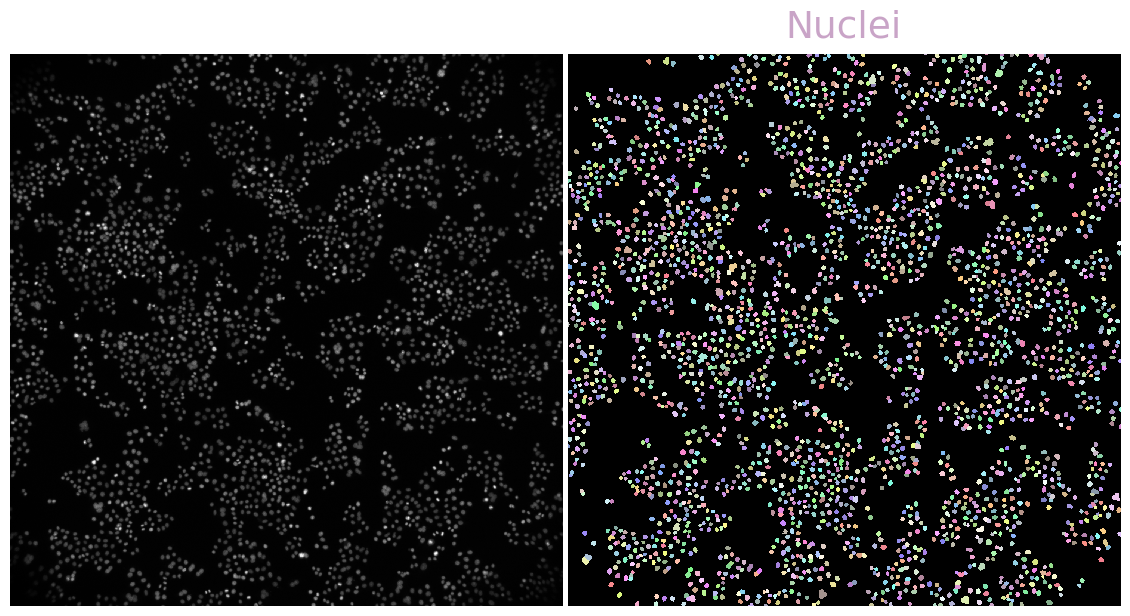

In [ ]:
print(f"Segmenting image with {SEGMENTATION_METHOD}...")

if SEGMENTATION_METHOD == "cellpose":
    nuclei = segment_cellpose(
        corrected_image_data,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        nuclei_diameter=NUCLEI_DIAMETER,
        cell_diameter=CELL_DIAMETER,
        cellpose_kwargs=dict(
            flow_threshold=FLOW_THRESHOLD,
            cellprob_threshold=CELLPROB_THRESHOLD,
        ),
        cyto_model=CELLPOSE_MODEL,
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "microsam":
    nuclei = segment_microsam(
        corrected_image_data,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        model_type=MICROSAM_MODEL,
        microsam_kwargs=dict(
            points_per_side=POINTS_PER_SIDE,
            points_per_batch=POINTS_PER_BATCH,
            stability_score_thresh=STABILITY_SCORE_THRESH,
            pred_iou_thresh=PRED_IOU_THRESH,
        ),
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "stardist":
    nuclei = segment_stardist(
        corrected_image_data,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        model_type=STARDIST_MODEL,
        stardist_kwargs=dict(
            prob_thresh=PROB_THRESH,
            nms_thresh=NMS_THRESH,
        ),
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "watershed":
    nuclei = segment_watershed(
        corrected_image_data,
        nuclei_threshold=THRESHOLD_DAPI,
        nuclei_area_min=NUCLEUS_AREA[0],
        nuclei_area_max=NUCLEUS_AREA[1],
        cell_threshold=THRESHOLD_CELL,
        cells=SEGMENT_CELLS,
    )


# Create and display micropanel of nuclei segmention
print("Example microplots for DAPI channel and nuclei segmentation:")
nuclei_cmap = random_cmap(num_colors=len(np.unique(nuclei)))
nuclei_seg_microimages = [
    Microimage(dapi_image, channel_names="Dapi"),
    Microimage(nuclei, cmaps=nuclei_cmap, channel_names="Nuclei"),
]
nuclei_seg_panel = create_micropanel(nuclei_seg_microimages, add_channel_label=True)
plt.show()

if SEGMENT_CELLS:
    # Create and display micropanel of segmented cells
    print("Example microplots for merged channels and cells segmentation:")
    cells_cmap = random_cmap(num_colors=len(np.unique(cells)))
    cells_seg_microimages = [
        Microimage(cellpose_rgb, channel_names="Merged"),
        Microimage(cells, cmaps=cells_cmap, channel_names="Cells"),
    ]
    cells_seg_panel = create_micropanel(cells_seg_microimages, add_channel_label=True)
    plt.show()

    # Create and display micropanel of annotated data
    print("Example microplot for sequencing data annotated with segmentation:")
    annotated_data = image_segmentation_annotations(cellpose_rgb[1:], nuclei, cells)
    annotated_microimage = [
        Microimage(
            annotated_data,
            channel_names="Merged",
            cmaps=["pure_blue", "pure_red", "pure_green"],
        )
    ]
    annotated_panel = create_micropanel(
        annotated_microimage, num_cols=1, figscaling=10, add_channel_label=False
    )
    plt.show()

## <font color='red'>SET PARAMETERS</font>

### Extract base intensity, call reads, assign to cells

- `DF_DESIGN_PATH`: The path to your guide RNA design file.
- `THRESHOLD_READS`: Initial threshold for detecting sequencing reads, set to 0 for preliminary analysis. This parameter will be optimized based on the mapping rate vs. peak threshold plot generated below. A higher threshold increases confidence in read calls but reduces the total number of detected reads.

In [27]:
# Define parameters for extracting bases
DF_DESIGN_PATH = "config/HeLa_combo_library_design.20240624-115737.csv"
THRESHOLD_READS = 50
CALL_READS_METHOD = "median"

In [28]:
# Read and format guide data
df_design = pd.read_csv(DF_DESIGN_PATH,index_col=None)
df_pool = df_design.drop(columns=['Unnamed: 0']).rename(columns={'target':'gene_symbol'})
df_pool['prefix_map'] = df_pool['iBAR_2']
df_pool['prefix_recomb'] = df_pool['iBAR_1'].str.slice(0,3)
barcodes = df_pool["prefix_recomb"] + df_pool["prefix_map"]

# Run extract_bases and call_reads with the default threshold
df_bases = extract_bases(
    peaks, maxed, nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
df_reads = call_reads(df_bases, peaks_data=peaks, method=CALL_READS_METHOD)

extract_bases.py (134): The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


The following plots will help determine the optimal `THRESHOLD_READS` value for your data:

Mapping rate vs. peak threshold for determining optimal peak cutoff:


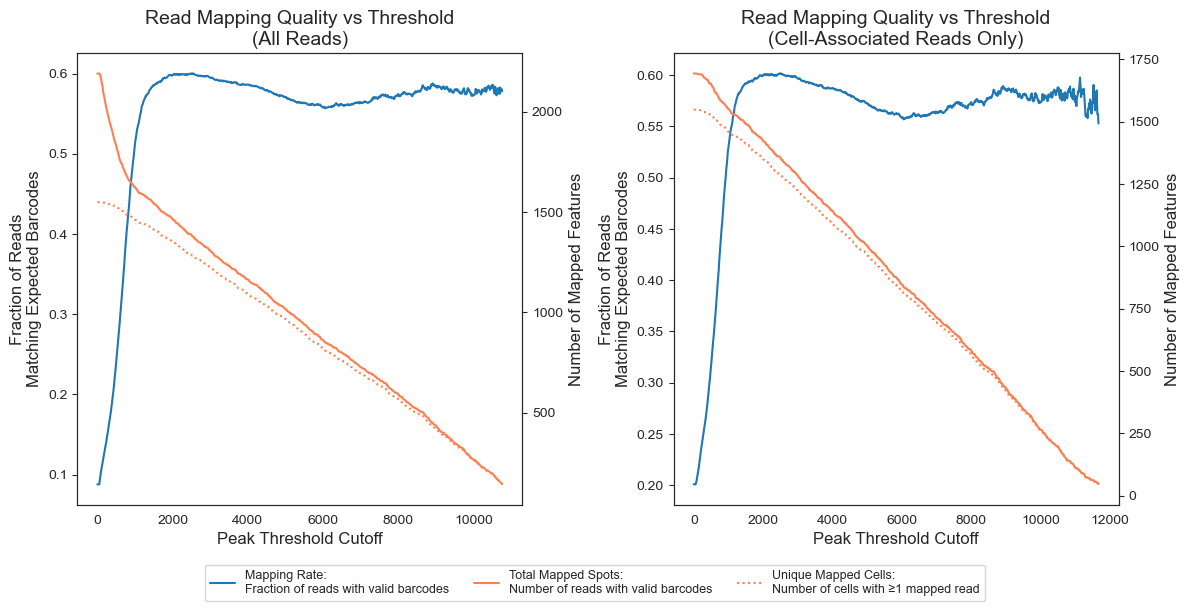

In [29]:
print("Mapping rate vs. peak threshold for determining optimal peak cutoff:")
plot_mapping_vs_threshold(df_reads, barcodes, "peak")
plt.show()

#### Left Plot (All Reads):
- Shows how the peak threshold affects all detected reads
- Blue line: Mapping rate (fraction of reads matching expected barcodes)
- Solid orange line: Total number of mapped spots (reads with valid barcodes)
- Dotted orange line: Number of unique cells with at least one mapped read

#### Right Plot (Cell-Associated Reads Only):
- Shows the same metrics but only for reads associated with cells

#### Setting Threshold Peaks:
Look for the point where the blue line (mapping rate) begins to plateau (~400)
- Consider the trade-off with number of mapped spots and cells
- A threshold around 300-500 typically provides a good balance:
  - Achieves ~75% mapping rate
  - Retains a reasonable number of mapped spots
  - Maintains coverage across cells

In [30]:
THRESHOLD_READS = 1400

Extracted bases:


extract_bases.py (134): The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


,read,cycle,channel,intensity,cell,i,j,tile,well
360,6,1,G,3438,0,8,1321,150,A1
361,6,1,T,1204,0,8,1321,150,A1
362,6,1,A,151,0,8,1321,150,A1
363,6,1,C,118,0,8,1321,150,A1
364,6,2,G,153,0,8,1321,150,A1
...,...,...,...,...,...,...,...,...,...
161395,2689,14,C,1227,2782,1472,861,150,A1
161396,2689,15,G,4498,2782,1472,861,150,A1
161397,2689,15,T,7402,2782,1472,861,150,A1
161398,2689,15,A,334,2782,1472,861,150,A1


Base intensity across cycles:


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


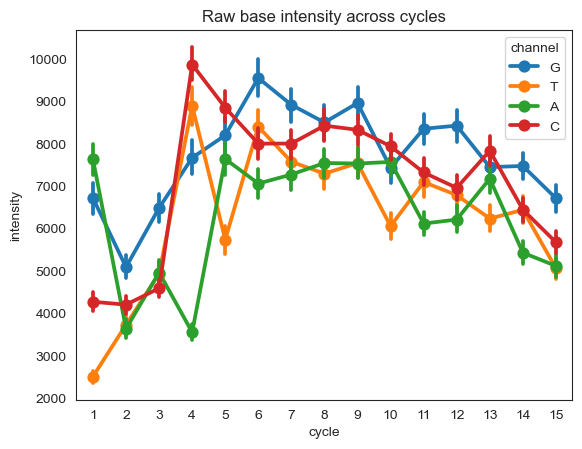

Intensity for each base:


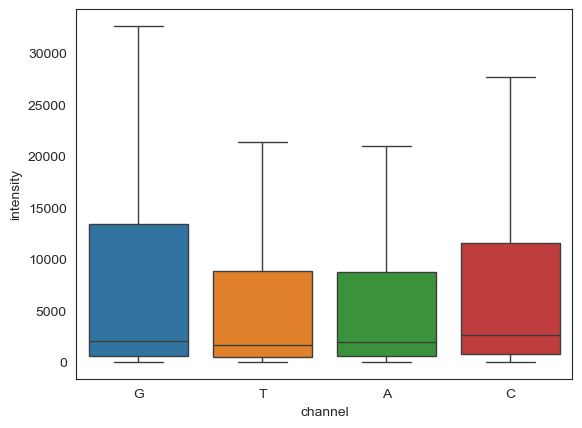

Called reads:


,read,cell,i,j,tile,well,barcode,Q_0,Q_1,Q_2,...,Q_7,Q_8,Q_9,Q_10,Q_11,Q_12,Q_13,Q_14,Q_min,peak
362,6,0,8,1321,150,A1,GAGTGTCGAAGAACG,1.0,1.00000,1.00000,...,1.0,1.00000,1.0,1.0,1.0,1.000000,0.73814,0.738140,0.738140,1546.713034
902,15,0,14,1303,150,A1,GAGTGTCGAAGAACG,1.0,0.73814,1.00000,...,1.0,1.00000,1.0,1.0,1.0,1.000000,1.00000,0.738140,0.738140,1710.297311
1622,27,0,23,239,150,A1,GCTTCACTACATCTG,1.0,0.73814,1.00000,...,1.0,1.00000,1.0,1.0,1.0,1.000000,1.00000,1.000000,0.738140,4347.093136
2942,49,0,46,1413,150,A1,GGGCTGGTGGAGACT,1.0,1.00000,1.00000,...,1.0,0.73814,1.0,1.0,1.0,1.000000,0.73814,0.738140,0.738140,1488.342597
3182,53,0,49,703,150,A1,AAACCACGGAATTAT,0.0,0.00000,0.00000,...,1.0,1.00000,1.0,1.0,1.0,1.000000,1.00000,1.000000,0.000000,1726.909423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161102,2685,2773,1470,1029,150,A1,ACCCTTCTGATCGTT,1.0,1.00000,1.00000,...,1.0,0.79588,1.0,1.0,1.0,1.000000,1.00000,1.000000,0.795880,5633.774187
161462,2691,2773,1474,1025,150,A1,ACCCTTCTGATCGTT,1.0,0.73814,0.73814,...,1.0,1.00000,1.0,1.0,1.0,1.000000,1.00000,1.000000,0.738140,2563.593027
161162,2686,2775,1470,1186,150,A1,GCTTATTGTAGCCGC,1.0,0.73814,1.00000,...,1.0,1.00000,1.0,1.0,1.0,1.000000,1.00000,0.634788,0.634788,4993.656816
161522,2692,2777,1474,1210,150,A1,ACTCTGGTACGAGCG,1.0,0.73814,1.00000,...,1.0,1.00000,1.0,1.0,1.0,0.943358,1.00000,1.000000,0.738140,3326.193930


In [40]:
# Re-run extract_bases and call_reads with the new threshold
print("Extracted bases:")
df_bases = extract_bases(
    peaks, maxed, nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
display(df_bases)

print("Base intensity across cycles:")
ax = sns.pointplot(x="cycle", y="intensity", hue="channel", data=df_bases)
plt.title("Raw base intensity across cycles")
plt.show()

print("Intensity for each base:")
ax = sns.boxplot(
    x="channel", y="intensity", hue="channel", data=df_bases, showfliers=False
)
plt.show()

print("Called reads:")
df_reads = call_reads(df_bases, peaks_data=peaks, method=CALL_READS_METHOD)
display(df_reads)

In [32]:
from lib.sbs.call_reads import clean_up_bases, dataframe_to_values, transform_medians, transform_medians, transform_percentiles

def get_normalized_bases(df_bases, method="median"):
    """Apply normalization to base intensities using specified method.
    
    Args:
        df_bases (pandas.DataFrame): DataFrame containing raw base signal intensities.
        method (str): Normalization method, either "median" or "percentile".
    
    Returns:
        pandas.DataFrame: DataFrame with normalized intensities and method label.
    """
    # Sort for preprocessing
    df_clean = clean_up_bases(df_bases)
    
    # Get dimensions
    cycles = len(set(df_bases["cycle"]))
    channels = len(set(df_bases["channel"]))
    
    # Create a copy of the DataFrame for normalization
    df_normalized = df_clean.copy()
    
    if method == "median":
        # Apply median normalization
        if "cell" in df_normalized.columns:
            # Get data for reads within cells
            X_in_cells = dataframe_to_values(df_normalized.query("cell > 0"))
            # Transform using median method
            Y_in_cells, W = transform_medians(X_in_cells.reshape(-1, channels))
            
            # Now apply this transformation to all data
            X_all = dataframe_to_values(df_normalized)
            Y_all = W.dot(X_all.reshape(-1, channels).T).T.astype(int)
            
            # Put the corrected values back in the DataFrame
            df_normalized["normalized_intensity"] = Y_all.flatten()
        else:
            # Just use all data if no cell column
            X = dataframe_to_values(df_normalized)
            Y, W = transform_medians(X.reshape(-1, channels))
            df_normalized["normalized_intensity"] = Y.flatten()
            
    elif method == "percentile":
        # Apply percentile normalization
        if "cell" in df_normalized.columns:
            # Get data for reads within cells
            X_in_cells = dataframe_to_values(df_normalized.query("cell > 0"))
            # Transform using percentile method
            Y_in_cells, W = transform_percentiles(X_in_cells.reshape(-1, channels))
            
            # Now apply this transformation to all data
            X_all = dataframe_to_values(df_normalized)
            Y_all = W.dot(X_all.reshape(-1, channels).T).T.astype(int)
            
            # Put the corrected values back in the DataFrame
            df_normalized["normalized_intensity"] = Y_all.flatten()
        else:
            # Just use all data if no cell column
            X = dataframe_to_values(df_normalized)
            Y, W = transform_percentiles(X.reshape(-1, channels))
            df_normalized["normalized_intensity"] = Y.flatten()
    else:
        raise ValueError(f"Unknown method: {method}. Use 'median' or 'percentile'.")
    
    # Add method label
    df_normalized["method"] = method
    
    return df_normalized

In [34]:
# Get normalized data for each method
median_normalized = get_normalized_bases(df_bases, method="median")
percentile_normalized = get_normalized_bases(df_bases, method="percentile")

call_reads.py (335): invalid value encountered in divide


In [35]:
display(median_normalized)

,read,cycle,channel,intensity,cell,i,j,tile,well,normalized_intensity,method
362,6,1,A,151,0,8,1321,150,A1,77,median
363,6,1,C,118,0,8,1321,150,A1,-53,median
360,6,1,G,3438,0,8,1321,150,A1,5036,median
361,6,1,T,1204,0,8,1321,150,A1,-148,median
366,6,2,A,2629,0,8,1321,150,A1,3997,median
...,...,...,...,...,...,...,...,...,...,...,...
161393,2689,14,T,18665,2782,1472,861,150,A1,31518,median
161398,2689,15,A,334,2782,1472,861,150,A1,82,median
161399,2689,15,C,523,2782,1472,861,150,A1,261,median
161396,2689,15,G,4498,2782,1472,861,150,A1,-730,median


In [36]:
display(percentile_normalized)

,read,cycle,channel,intensity,cell,i,j,tile,well,normalized_intensity,method
362,6,1,A,151,0,8,1321,150,A1,123,percentile
363,6,1,C,118,0,8,1321,150,A1,6,percentile
360,6,1,G,3438,0,8,1321,150,A1,4500,percentile
361,6,1,T,1204,0,8,1321,150,A1,281,percentile
366,6,2,A,2629,0,8,1321,150,A1,3766,percentile
...,...,...,...,...,...,...,...,...,...,...,...
161393,2689,14,T,18665,2782,1472,861,150,A1,28905,percentile
161398,2689,15,A,334,2782,1472,861,150,A1,177,percentile
161399,2689,15,C,523,2782,1472,861,150,A1,343,percentile
161396,2689,15,G,4498,2782,1472,861,150,A1,303,percentile


Base intensity across cycles:


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


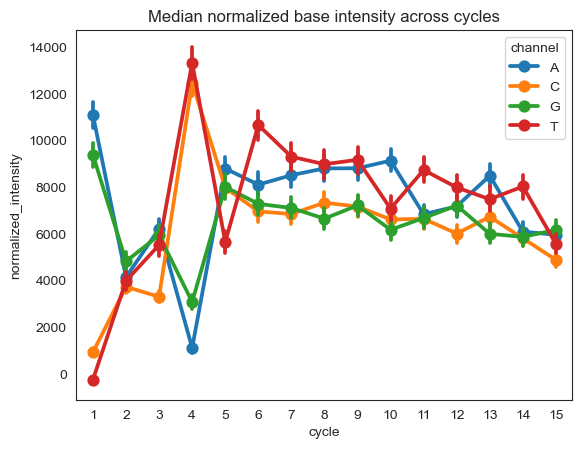

In [41]:
print("Base intensity across cycles:")
ax = sns.pointplot(x="cycle", y="normalized_intensity", hue="channel", data=median_normalized)
plt.title("Median normalized base intensity across cycles")
plt.show()

Base intensity across cycles:


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


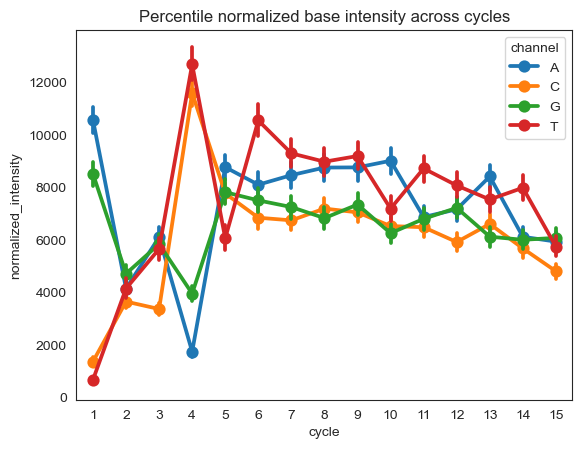

In [42]:
print("Base intensity across cycles:")
ax = sns.pointplot(x="cycle", y="normalized_intensity", hue="channel", data=percentile_normalized)
plt.title("Percentile normalized base intensity across cycles")
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Read mapping

- `Q_MIN`: The minimum quality score for each base read. Calculated as 1 - [log2(2 + second) / log2(2 + first)]. Default is 0 and typically remains unchanged. While the Q_min plot above shows the relationship between Q_min and mapping rate, adjusting THRESHOLD_READS is the preferred method for quality control. Higher Q_min values are more stringent but can excessively filter valid reads.

The following plots will help determine the optimal `Q_MIN` value for your data:

Mapping rate vs. Q_min for determining optimal sequence quality cutoff:


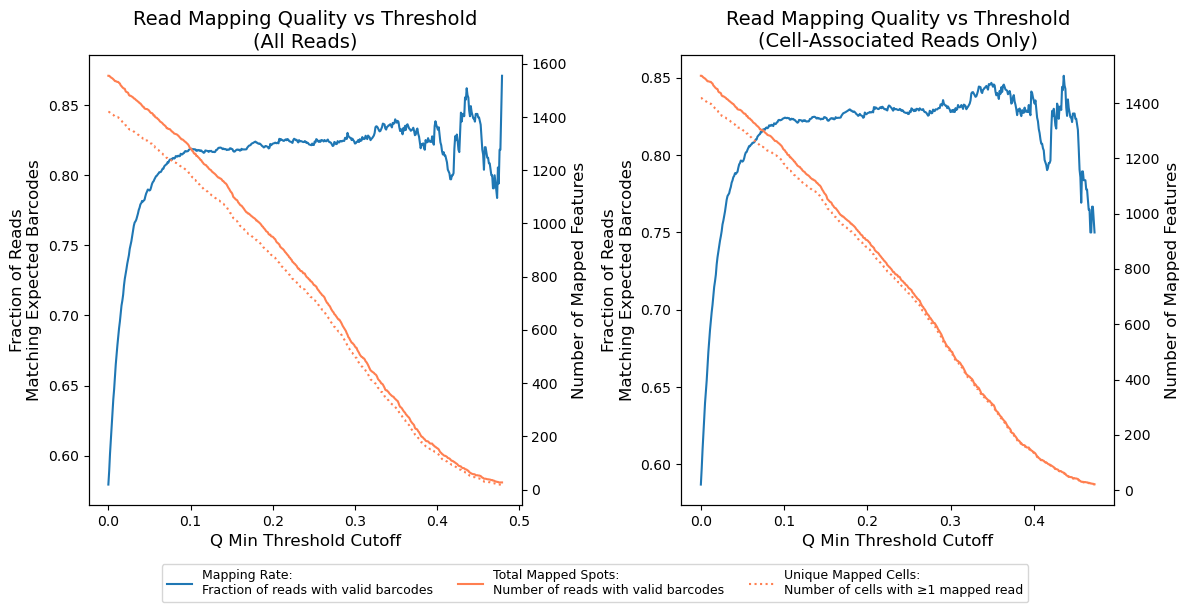

In [17]:
print("Mapping rate vs. Q_min for determining optimal sequence quality cutoff:")
plot_mapping_vs_threshold(df_reads, barcodes, "Q_min")
plt.show()

#### Left Plot (All Reads):
- Shows how Q_min threshold affects all detected reads
- Blue line: Mapping rate (fraction of reads matching expected barcodes)
- Solid red line: Total number of mapped spots (reads with valid barcodes)
- Dotted red line: Number of unique cells with at least one mapped read

#### Right Plot (Cell-Associated Reads Only):
- Shows the same metrics but only for reads associated with cells

#### Interpreting Q_min Results:
With our optimized peak threshold, these plots confirm that adjusting Q_min provides little benefit:
- The mapping rate (blue line) is already very high at Q_min = 0
- Increasing Q_min only marginally improves mapping rate 
- However, this comes at a significant cost:
  - Total mapped spots and mapped cells decreases substantially
- The small gain in mapping rate doesn't justify the large loss of data

### To move to main

In [18]:
# # Define parameters for read mapping
# Q_MIN = 0
# BARCODE_COL = 'sgRNA'
# DF_UMI = None
# ERROR_CORRECT = False
# # Define further error correction parameters if wanted (e.g. MAX_DISTANCE, DISTANCE_METRIC)

In [19]:
# print("Corrected cells:")
# df_cells = call_cells(
#     df_reads, 
#     df_pool=df_pool, 
#     q_min=Q_MIN,
#     barcode_col=BARCODE_COL,
#     df_UMI=DF_UMI,
#     error_correct=ERROR_CORRECT,
# )
# display(df_cells)

# print("Minimal phenotype features:")
# df_sbs_info = extract_phenotype_minimal(
#     phenotype_data=nuclei, nuclei_data=nuclei, wildcards=WILDCARDS
# )
# display(df_sbs_info)

# print("Summary of the fraction of cells mapping to one barcode:")
# one_barcode_mapping = plot_cell_mapping_heatmap(
#     df_cells,
#     df_sbs_info,
#     barcodes,
#     mapping_to="one",
#     mapping_strategy="gene symbols",
#     shape="6W_sbs",
#     return_plot=False,
#     return_summary=True,
# )
# display(one_barcode_mapping)

# print("Summary of the fraction of cells mapping to any barcode:")
# any_barcode_mapping = plot_cell_mapping_heatmap(
#     df_cells,
#     df_sbs_info,
#     barcodes,
#     mapping_to="any",
#     mapping_strategy="gene symbols",
#     shape="6W_sbs",
#     return_plot=False,
#     return_summary=True,
# )
# display(any_barcode_mapping)

# print("Histogram of the number of reads per cell:")
# outliers = plot_reads_per_cell_histogram(df_cells, x_cutoff=20)
# plt.show()

# print("Histogram of the number of counts of each unique gene symbols:")
# outliers = plot_gene_symbol_histogram(df_cells, x_cutoff=30)
# plt.show()

In [20]:
# Define parameters for preparing reads dataframe
RECOMB_START = 1
RECOMB_END = 3
MAP_START = 4
MAP_END = 15
MAP_COL = 'prefix_map'
RECOMB_COL = 'prefix_recomb'
RECOMB_FILTER_COL = 'Q_recomb'
# Define parameters for read mapping
Q_MIN = 0
ERROR_CORRECT = True
RECOMB_Q_THRESHOLD = 0.5
BARCODE_INFO_COLS = ['gene_symbol','target_version']
# Define further error correction parameters if wanted (e.g. MAX_DISTANCE, DISTANCE_METRIC)
MAX_DISTANCE = 2

Preparing reads
Corrected cells:
performing error correction


call_cells_T7.py (191): Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.


,cell,tile,well,prefix_recomb,cell_barcode_0,pre_correction_cell_barcode_0,no_recomb_0,peak_0,cell_barcode_1,no_recomb_1,peak_1,gene_symbol_0,gene_symbol_1
0,2,150,A1,ATA,TGTATACGCAAT,TGTATACGCAAA,True,2019.437829,NaN,NaN,NaN,NDUFS7,NaN
1,3,150,A1,ATA,CTTCCACATGCG,CTTCCACATGCA,NaN,10446.835968,NaN,NaN,NaN,SHOX2_SHOX,NaN
2,11,150,A1,GGT,TGCGTTTGGTGT,TGCGTTTGGTGT,NaN,6917.921532,NaN,NaN,NaN,GRK2,NaN
3,14,150,A1,GGT,TGCGTTTGGTGT,TGCGTTTGGTGA,NaN,6118.179269,NaN,NaN,NaN,GRK2,NaN
4,16,150,A1,GGT,TGCGTTTGGTGT,TGCGTTTGGTGT,NaN,4472.109376,NaN,NaN,NaN,GRK2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284,2772,150,A1,GTT,TACACCAAGATT,TACACCAAGATT,NaN,4111.566683,NaN,NaN,NaN,KCTD2,NaN
2285,2773,150,A1,ACC,CTTCTGATCGTT,CTTCTGATCGTT,True,5633.774187,CTTCTGATCGTT,NaN,2563.593027,NONTARGETING_CONTROL,NONTARGETING_CONTROL
2286,2775,150,A1,GCT,TATTGTAGCCGC,TATTGTAGCCGC,NaN,4993.656816,NaN,NaN,NaN,SEC23B,NaN
2287,2777,150,A1,ACT,CTGGTACGAGCG,CTGGTACGAGCG,True,3326.193930,NaN,NaN,NaN,CEPT1_CHPT1,NaN


Minimal phenotype features:


,area,i,j,cell,bounds,tile,well
0,72.0,2.638889,401.361111,1,"(0, 396, 7, 408)",150,A1
1,117.0,3.820513,484.478632,2,"(0, 478, 10, 492)",150,A1
2,95.0,3.126316,550.021053,3,"(0, 544, 8, 558)",150,A1
3,55.0,1.981818,686.818182,4,"(0, 681, 6, 693)",150,A1
4,65.0,2.076923,956.861538,5,"(0, 951, 6, 964)",150,A1
...,...,...,...,...,...,...,...
2780,97.0,1475.556701,811.701031,2781,"(1471, 806, 1480, 819)",150,A1
2781,93.0,1474.956989,862.645161,2782,"(1470, 858, 1480, 869)",150,A1
2782,64.0,1476.437500,980.968750,2783,"(1472, 975, 1480, 987)",150,A1
2783,88.0,1475.761364,996.704545,2784,"(1472, 991, 1480, 1004)",150,A1


Summary of the fraction of cells mapping to one barcode:


,well,tile,fraction of cells mapping to 1 gene symbols
0,A1,150,0.675763


Summary of the fraction of cells mapping to any barcode:


,well,tile,fraction of cells mapping to >=1 gene symbols
0,A1,150,0.728187


Histogram of the number of counts of each unique gene symbols:


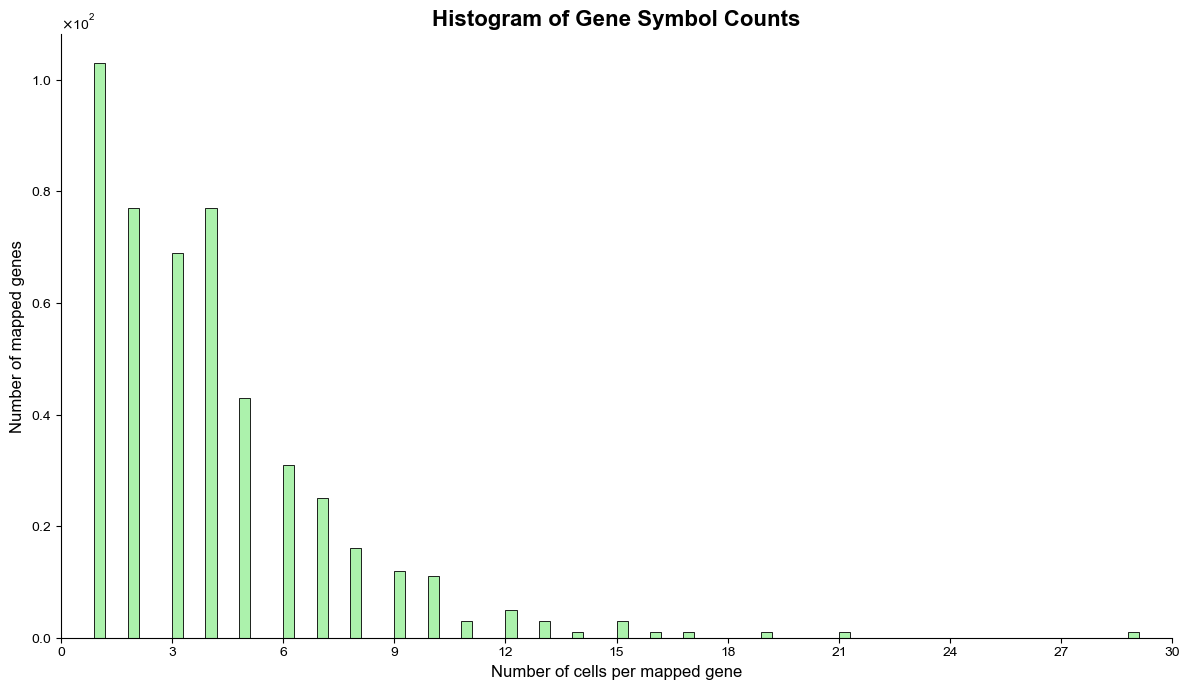

In [21]:
print("Preparing reads")
df_reads_T7 = prep_T7_reads(
    df_reads,
    map_start=MAP_START,
    map_end=MAP_END,
    recomb_start=RECOMB_START,
    recomb_end=RECOMB_END,
    map_col=MAP_COL,
    recomb_col=RECOMB_COL
)

print("Corrected cells:")
df_cells = call_cells_T7(
    df_reads_T7, 
    df_pool=df_pool, 
    q_min=Q_MIN,
    map_col=MAP_COL,
    error_correct=ERROR_CORRECT,
    recomb_col=RECOMB_COL,
    recomb_filter_col=RECOMB_FILTER_COL,
    recomb_q_thresh=RECOMB_Q_THRESHOLD,
)
display(df_cells)

print("Minimal phenotype features:")
df_sbs_info = extract_phenotype_minimal(
    phenotype_data=nuclei, nuclei_data=nuclei, wildcards=WILDCARDS
)
display(df_sbs_info)

print("Summary of the fraction of cells mapping to one barcode:")
one_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="one",
    mapping_strategy="gene symbols",
    shape="6W_sbs",
    return_plot=False,
    return_summary=True,
)
display(one_barcode_mapping)

print("Summary of the fraction of cells mapping to any barcode:")
any_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="any",
    mapping_strategy="gene symbols",
    shape="6W_sbs",
    return_plot=False,
    return_summary=True,
)
display(any_barcode_mapping)

print("Histogram of the number of counts of each unique gene symbols:")
outliers = plot_gene_symbol_histogram(df_cells, x_cutoff=30)
plt.show()

In [21]:
# print("Histogram of the number of reads per cell:")
# outliers = plot_reads_per_cell_histogram(df_cells, x_cutoff=20)
# plt.show()

## Add sbs process parameters to config file

The `mode` parameter in the config file determines how Snakemake will execute parameter searches for segmentation optimization. Setting the `mode` to `segment_sbs_paramsearch` will systematically explore combinations of:

1. Size Parameters:
   - `nuclei_diameter`: Expected diameter of cell nuclei
   - `cell_diameter`: Expected diameter of cell cytoplasm
   
2. CellPose Parameters:
   - `flow_threshold`: Controls sensitivity of segmentation boundaries (default value 0.4)
     - Lower values: More aggressive segmentation, may over-segment
     - Higher values: More conservative, may miss cell boundaries
   - `cellprob_threshold`: Controls cell detection confidence (default value 0)
     - Lower values: Detects more potential cells, may include false positives
     - Higher values: More stringent detection, may miss weaker signals

The parameter search will:
1. Generate segmentations using different parameter combinations
2. Save results for each combination
3. Allow you to visually inspect results to choose optimal values
4. Help identify the best balance between over- and under-segmentation

Running these parameter searches is a time and resource intensive process and should only be done on a small subset of the tiles in the dataset.

In [ ]:
# Add sbs section
config["sbs"] = {
    "alignment_method": ALIGNMENT_METHOD,
    "keep_extras": KEEP_EXTRAS,
    "upsample_factor": UPSAMPLE_FACTOR,
    "peak_width": PEAK_WIDTH,
    "maxed_width": MAXED_WIDTH,
    "segmentation_method": SEGMENTATION_METHOD,
    "segmentation_cycle_index": SEGMENTATION_CYCLE_INDEX,
    "dapi_index": DAPI_INDEX,
    "cyto_index": CYTO_INDEX,
    "gpu": GPU,
    "reconcile": RECONCILE,
    "segment_cells": SEGMENT_CELLS,
    "mode": None,
    "df_design_path": DF_DESIGN_PATH,
    "threshold_peaks": THRESHOLD_READS,
    "bases": BASES,
    "call_reads_method": CALL_READS_METHOD,
    "recomb_start": RECOMB_START,
    "recomb_end": RECOMB_END,
    "map_start": MAP_START,
    "map_end": MAP_END,
    "map_col": MAP_COL,
    "recomb_col": RECOMB_COL,
    "recomb_filter_col": RECOMB_FILTER_COL,
    "q_min": Q_MIN,
    "error_correct": ERROR_CORRECT,
    "recomb_q_thresh": RECOMB_Q_THRESHOLD,
    "barcode_info_cols": BARCODE_INFO_COLS,
    "max_distance": MAX_DISTANCE,
}

# Add method-specific parameters based on segmentation method
if SEGMENTATION_METHOD == "cellpose":
    config["sbs"].update({
        "cellpose_model": CELLPOSE_MODEL,
        "nuclei_diameter": NUCLEI_DIAMETER,
        "cell_diameter": CELL_DIAMETER,
        "flow_threshold": FLOW_THRESHOLD,
        "cellprob_threshold": CELLPROB_THRESHOLD,
    })
elif SEGMENTATION_METHOD == "microsam":
    config["sbs"].update({
        "microsam_model": MICROSAM_MODEL,
        "points_per_side": POINTS_PER_SIDE,
        "points_per_batch": POINTS_PER_BATCH,
        "stability_score_thresh": STABILITY_SCORE_THRESH,
        "pred_iou_thresh": PRED_IOU_THRESH,
    })
elif SEGMENTATION_METHOD == "stardist":
    config["sbs"].update({
        "stardist_model": STARDIST_MODEL,
        "prob_thresh": PROB_THRESH,
        "nms_thresh": NMS_THRESH,
    })
elif SEGMENTATION_METHOD == "watershed":
    config["sbs"].update({
        "threshold_dapi": THRESHOLD_DAPI,
        "nucleus_area_min": NUCLEUS_AREA[0],
        "nucleus_area_max": NUCLEUS_AREA[1],
        "threshold_cell": THRESHOLD_CELL,
    })

# Write the updated configuration back with markdown-style comments
with open(CONFIG_FILE_PATH, "w") as config_file:
    # Write the introductory markdown-style comments
    config_file.write(CONFIG_FILE_HEADER)

    # Dump the updated YAML structure, keeping markdown comments for sections
    yaml.dump(config, config_file, default_flow_style=False)